In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="talk")

In [2]:
df = pd.read_csv("../datos/datos_modelo1/raw/aldimi_demand_dataset.csv")

In [3]:
df.head()

,fecha,dia_semana,es_fin_de_semana,n_total,n_low,n_medium,n_high,n_presentes,N02BE_demand,N05B_demand,M01AB_demand,total_demand
0,2014-01-02,3,0,103,63,24,16,103,222.17,15.35,0.12,237.64
1,2014-01-03,4,0,104,64,24,16,104,347.97,35.60,25.48,409.05
2,2014-01-04,5,1,101,60,26,15,65,268.73,19.84,6.37,294.94
3,2014-01-05,6,1,101,60,26,15,69,187.14,16.71,12.45,216.30
4,2014-01-06,0,0,100,60,26,14,100,147.13,37.07,13.49,197.69


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             2106 non-null   object 
 1   dia_semana        2106 non-null   int64  
 2   es_fin_de_semana  2106 non-null   int64  
 3   n_total           2106 non-null   int64  
 4   n_low             2106 non-null   int64  
 5   n_medium          2106 non-null   int64  
 6   n_high            2106 non-null   int64  
 7   n_presentes       2106 non-null   int64  
 8   N02BE_demand      2106 non-null   float64
 9   N05B_demand       2106 non-null   float64
 10  M01AB_demand      2106 non-null   float64
 11  total_demand      2106 non-null   float64
dtypes: float64(4), int64(7), object(1)
memory usage: 197.6+ KB


In [5]:
df.describe()

,dia_semana,es_fin_de_semana,n_total,n_low,n_medium,n_high,n_presentes,N02BE_demand,N05B_demand,M01AB_demand,total_demand
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,3.000475,0.285850,102.430674,50.519943,29.347104,22.563628,94.003324,186.112906,25.216614,22.840285,234.169805
std,2.000831,0.451926,2.245754,5.582023,4.441612,4.410201,13.636178,95.803974,16.023209,13.730142,101.772800
min,0.000000,0.000000,95.000000,35.000000,18.000000,11.000000,62.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,101.000000,47.000000,26.000000,20.000000,78.000000,115.917500,13.607500,12.562500,164.857500
50%,3.000000,0.000000,103.000000,51.000000,29.000000,22.000000,101.000000,169.180000,22.740000,20.820000,219.395000
75%,5.000000,1.000000,104.000000,54.000000,32.000000,26.000000,104.000000,240.590000,33.217500,30.595000,291.770000
max,6.000000,1.000000,108.000000,66.000000,42.000000,36.000000,108.000000,1120.320000,177.220000,96.320000,1184.180000


In [6]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def temporal_train_test_split(X, y, test_size=0.2):
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
    y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()
    return X_train, X_test, y_train, y_test


def summarize_metrics(model_name, horizon, y_true, y_pred):
    return {
        "Model": model_name,
        "Horizon_days": horizon,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
    }


def plot_predictions(pred_df, title, last_n=120):
    view = pred_df.tail(last_n)
    plt.figure(figsize=(14, 5))
    plt.plot(view.index, view["actual"], label="Real", linewidth=2)
    plt.plot(view.index, view["predicted"], label="Prediccion", linewidth=2)
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Demanda")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Para Low Risk, Medium Riks y High Risk (N02BE)

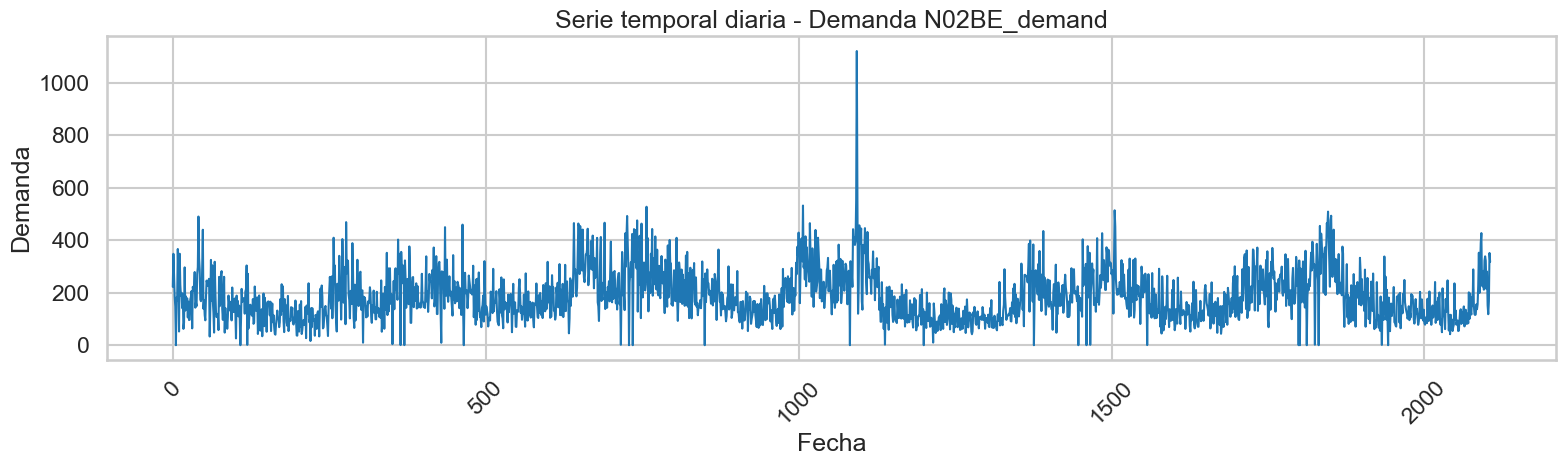

In [7]:
plt.figure(figsize=(16, 5))
plt.plot(df.index, df["N02BE_demand"], color="#1f77b4", linewidth=1.5)
plt.title(f"Serie temporal diaria - Demanda {"N02BE_demand"}")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

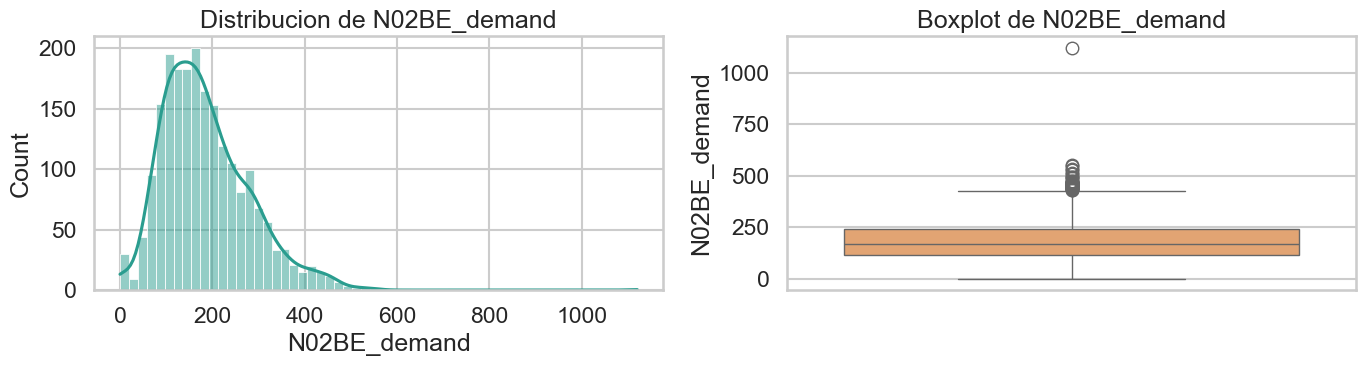

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["N02BE_demand"], kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title(f"Distribucion de {"N02BE_demand"}")

sns.boxplot(y=df["N02BE_demand"], ax=axes[1], color="#f4a261")
axes[1].set_title(f"Boxplot de {"N02BE_demand"}")
plt.tight_layout()
plt.show()

## Para Medium Risk y High Risk (N05B)

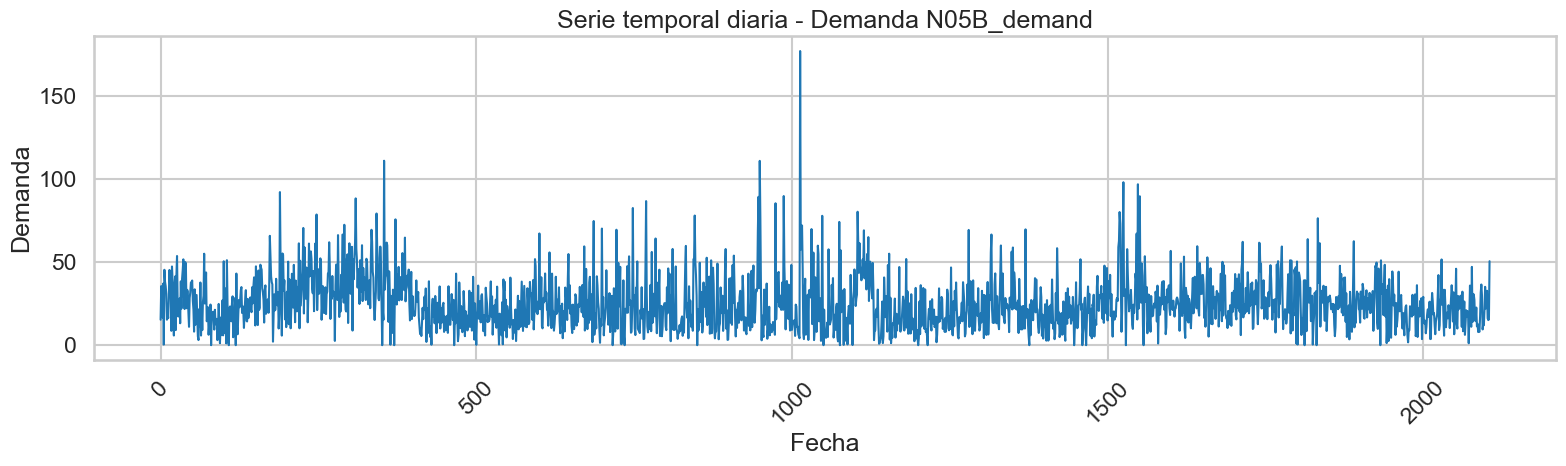

In [9]:
plt.figure(figsize=(16, 5))
plt.plot(df.index, df["N05B_demand"], color="#1f77b4", linewidth=1.5)
plt.title(f"Serie temporal diaria - Demanda {"N05B_demand"}")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

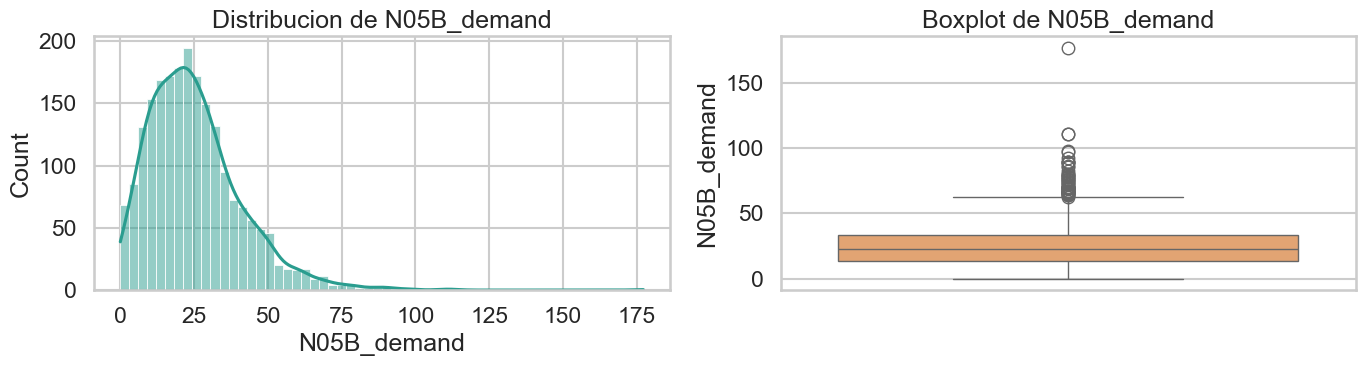

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["N05B_demand"], kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title(f"Distribucion de {"N05B_demand"}")

sns.boxplot(y=df["N05B_demand"], ax=axes[1], color="#f4a261")
axes[1].set_title(f"Boxplot de {"N05B_demand"}")
plt.tight_layout()
plt.show()

## Para High Risk (M01AB)

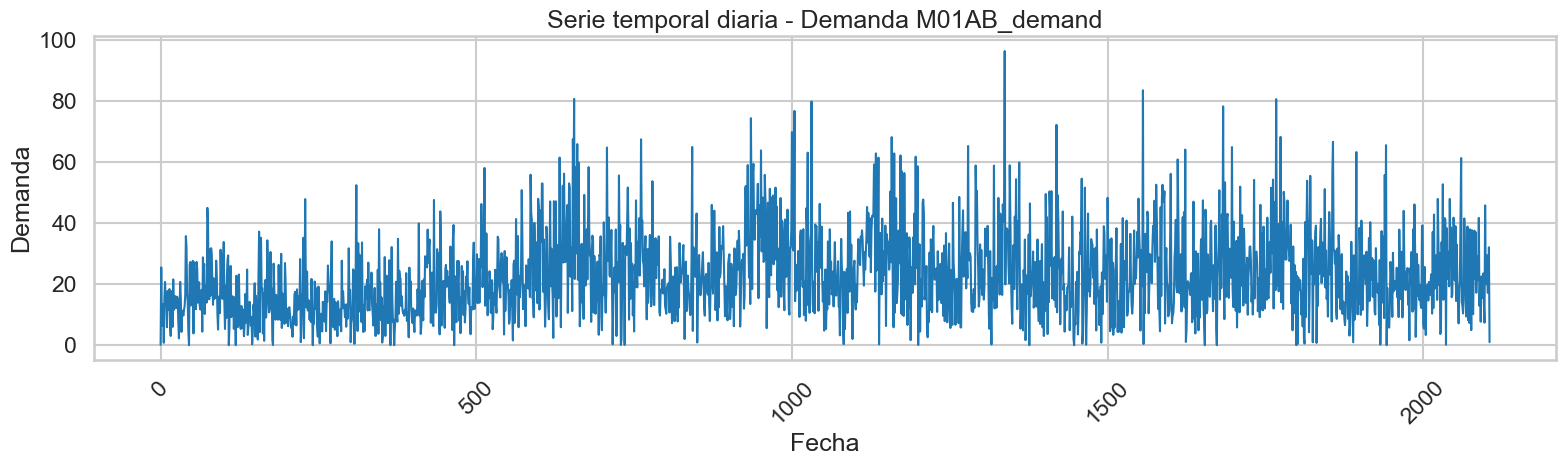

In [11]:
plt.figure(figsize=(16, 5))
plt.plot(df.index, df["M01AB_demand"], color="#1f77b4", linewidth=1.5)
plt.title(f"Serie temporal diaria - Demanda {"M01AB_demand"}")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

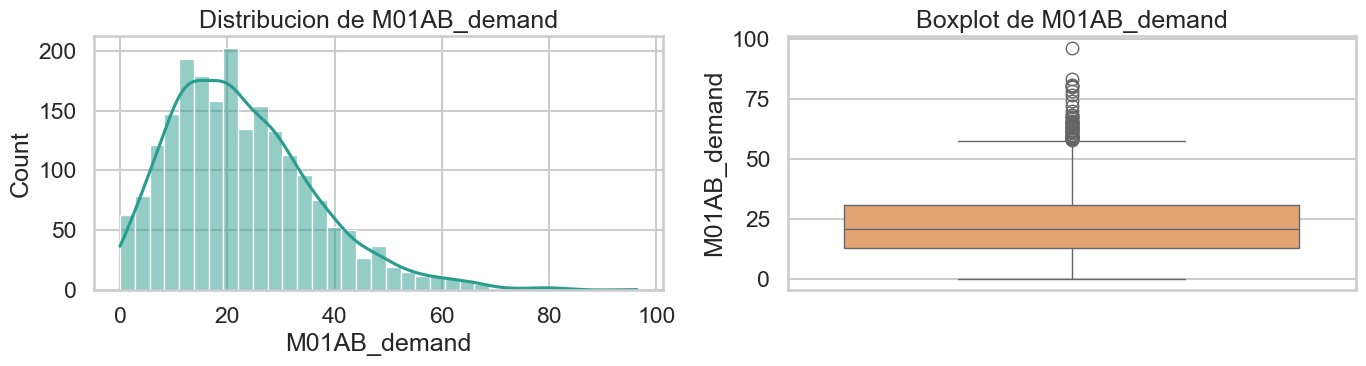

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["M01AB_demand"], kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title(f"Distribucion de {"M01AB_demand"}")

sns.boxplot(y=df["M01AB_demand"], ax=axes[1], color="#f4a261")
axes[1].set_title(f"Boxplot de {"M01AB_demand"}")
plt.tight_layout()
plt.show()

## Limpiamos Outliers con capeo de Bigote superior

In [13]:
cols_demanda = ['N02BE_demand', 'N05B_demand', 'M01AB_demand']

for col in cols_demanda:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    outliers_count = (df[col] > limite_superior).sum()
    df[col] = df[col].clip(upper=limite_superior)
    
    print(f"Columna {col}:")
    print(f"  - Limite superior calculado: {limite_superior:.2f}")
    print(f"  - Valores ajustados: {outliers_count}")
    print("-" * 30)
print("\nResumen estadistico tras la limpieza:")
print(df[cols_demanda].describe())


Columna N02BE_demand:
  - Limite superior calculado: 427.60
  - Valores ajustados: 41
------------------------------
Columna N05B_demand:
  - Limite superior calculado: 62.63
  - Valores ajustados: 50
------------------------------
Columna M01AB_demand:
  - Limite superior calculado: 57.64
  - Valores ajustados: 45
------------------------------

Resumen estadistico tras la limpieza:
       N02BE_demand  N05B_demand  M01AB_demand
count   2106.000000  2106.000000   2106.000000
mean     185.052412    24.843682     22.658703
std       91.595942    14.661620     13.147609
min        0.000000     0.000000      0.000000
25%      115.917500    13.607500     12.562500
50%      169.180000    22.740000     20.820000
75%      240.590000    33.217500     30.595000
max      427.598750    62.632500     57.643750


### Distribuciones nuevas

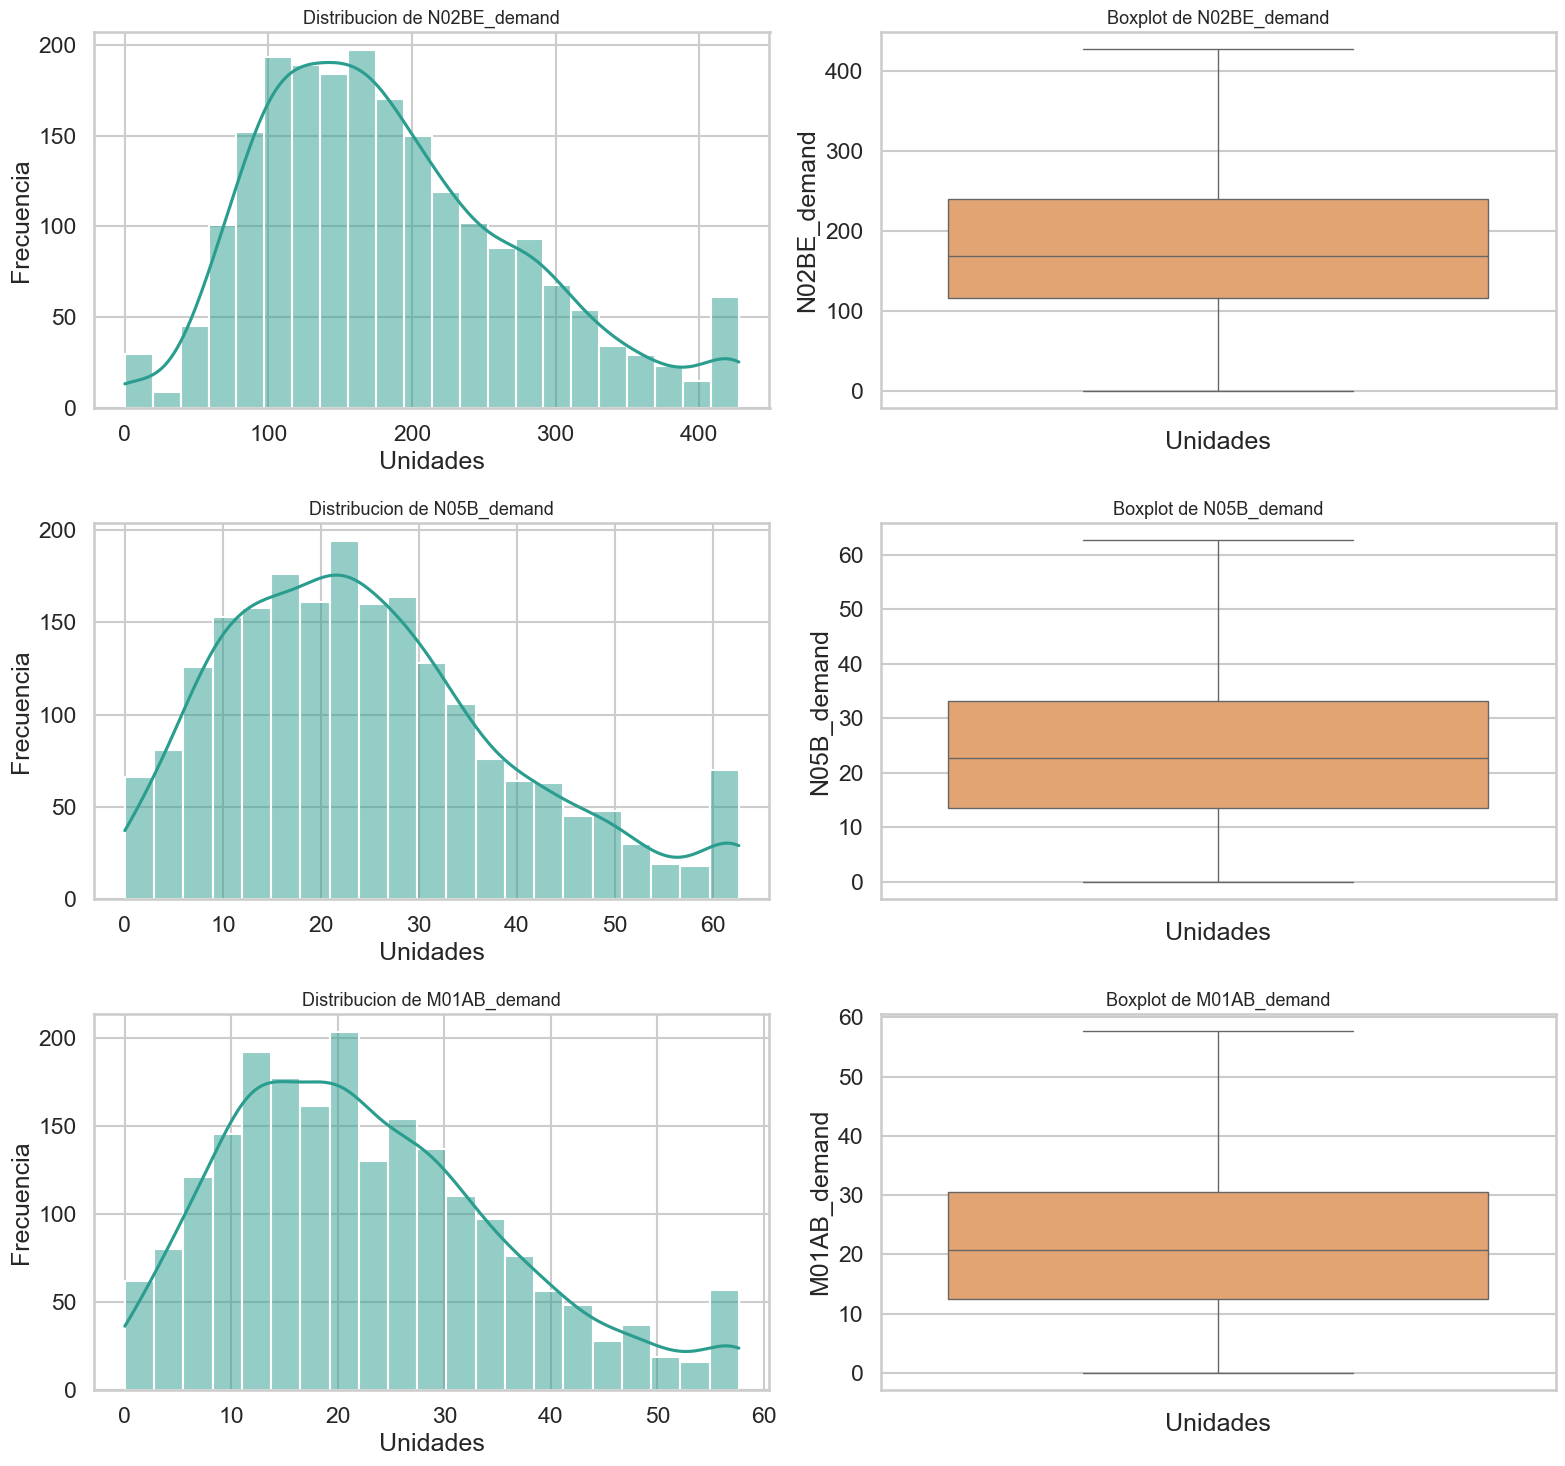

In [14]:
cols_demanda = ['N02BE_demand', 'N05B_demand', 'M01AB_demand']
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
color_hist = "#2a9d8f"
color_box = "#f4a261"
for i, col in enumerate(cols_demanda):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color=color_hist)
    axes[i, 0].set_title(f"Distribucion de {col}", fontsize=13)
    axes[i, 0].set_xlabel("Unidades")
    axes[i, 0].set_ylabel("Frecuencia")
    
    sns.boxplot(y=df[col], ax=axes[i, 1], color=color_box)
    axes[i, 1].set_title(f"Boxplot de {col}", fontsize=13)
    axes[i, 1].set_xlabel("Unidades")
plt.tight_layout()
plt.show()

## Feature Engineering

In [15]:
df['fecha'] = pd.to_datetime(df['fecha'])

dias_map = {
    0: 'Lunes', 1: 'Martes', 2: 'Miercoles', 3: 'Jueves',
    4: 'Viernes', 5: 'Sabado', 6: 'Domingo'
}

df['nombre_dia'] = df['dia_semana'].map(dias_map)

df['mes'] = df['fecha'].dt.month

df.info()
display(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             2106 non-null   datetime64[ns]
 1   dia_semana        2106 non-null   int64         
 2   es_fin_de_semana  2106 non-null   int64         
 3   n_total           2106 non-null   int64         
 4   n_low             2106 non-null   int64         
 5   n_medium          2106 non-null   int64         
 6   n_high            2106 non-null   int64         
 7   n_presentes       2106 non-null   int64         
 8   N02BE_demand      2106 non-null   float64       
 9   N05B_demand       2106 non-null   float64       
 10  M01AB_demand      2106 non-null   float64       
 11  total_demand      2106 non-null   float64       
 12  nombre_dia        2106 non-null   object        
 13  mes               2106 non-null   int32         
dtypes: datetime64[ns](1), fl

,fecha,dia_semana,es_fin_de_semana,n_total,n_low,n_medium,n_high,n_presentes,N02BE_demand,N05B_demand,M01AB_demand,total_demand,nombre_dia,mes
0,2014-01-02,3,0,103,63,24,16,103,222.17,15.35,0.12,237.64,Jueves,1
1,2014-01-03,4,0,104,64,24,16,104,347.97,35.60,25.48,409.05,Viernes,1
2,2014-01-04,5,1,101,60,26,15,65,268.73,19.84,6.37,294.94,Sabado,1
3,2014-01-05,6,1,101,60,26,15,69,187.14,16.71,12.45,216.30,Domingo,1
4,2014-01-06,0,0,100,60,26,14,100,147.13,37.07,13.49,197.69,Lunes,1


In [16]:
medicamentos = ['N02BE_demand', 'N05B_demand', 'M01AB_demand']
display(df.shape)
for med in medicamentos:
    df[f'{med}_lag1'] = df[med].shift(1)
    df[f'{med}_lag7'] = df[med].shift(7)
    df[f'{med}_rolling7'] = df[med].rolling(window=7).mean()

df_clean = df.dropna().copy()

print("Nuevas columnas generadas:")
print(df_clean.columns.tolist())
print(f"\nTotal filas tras limpiar NaNs: {len(df_clean)}")

(2106, 14)

Nuevas columnas generadas:
['fecha', 'dia_semana', 'es_fin_de_semana', 'n_total', 'n_low', 'n_medium', 'n_high', 'n_presentes', 'N02BE_demand', 'N05B_demand', 'M01AB_demand', 'total_demand', 'nombre_dia', 'mes', 'N02BE_demand_lag1', 'N02BE_demand_lag7', 'N02BE_demand_rolling7', 'N05B_demand_lag1', 'N05B_demand_lag7', 'N05B_demand_rolling7', 'M01AB_demand_lag1', 'M01AB_demand_lag7', 'M01AB_demand_rolling7']

Total filas tras limpiar NaNs: 2099


In [17]:
df_clean.head()

,fecha,dia_semana,es_fin_de_semana,n_total,n_low,n_medium,n_high,n_presentes,N02BE_demand,N05B_demand,M01AB_demand,total_demand,nombre_dia,mes,N02BE_demand_lag1,N02BE_demand_lag7,N02BE_demand_rolling7,N05B_demand_lag1,N05B_demand_lag7,N05B_demand_rolling7,M01AB_demand_lag1,M01AB_demand_lag7,M01AB_demand_rolling7
7,2014-01-09,3,0,103,60,28,15,103,171.11,38.15,20.70,229.96,Jueves,1,181.34,222.17,186.202857,45.42,15.35,27.592857,15.56,0.12,13.545714
8,2014-01-10,4,0,103,60,28,15,103,366.32,35.62,14.82,416.76,Viernes,1,171.11,347.97,188.824286,38.15,35.60,27.595714,20.70,25.48,12.022857
9,2014-01-11,5,1,100,58,29,13,70,245.55,30.90,14.14,290.59,Sabado,1,366.32,268.73,185.512857,35.62,19.84,29.175714,14.82,6.37,13.132857
10,2014-01-12,6,1,99,58,28,13,63,52.12,15.36,5.87,73.35,Domingo,1,245.55,187.14,166.224286,30.90,16.71,28.982857,14.14,12.45,12.192857
11,2014-01-13,0,0,101,59,30,12,101,348.30,20.28,17.73,386.31,Lunes,1,52.12,147.13,194.962857,15.36,37.07,26.584286,5.87,13.49,12.798571


## Más eda

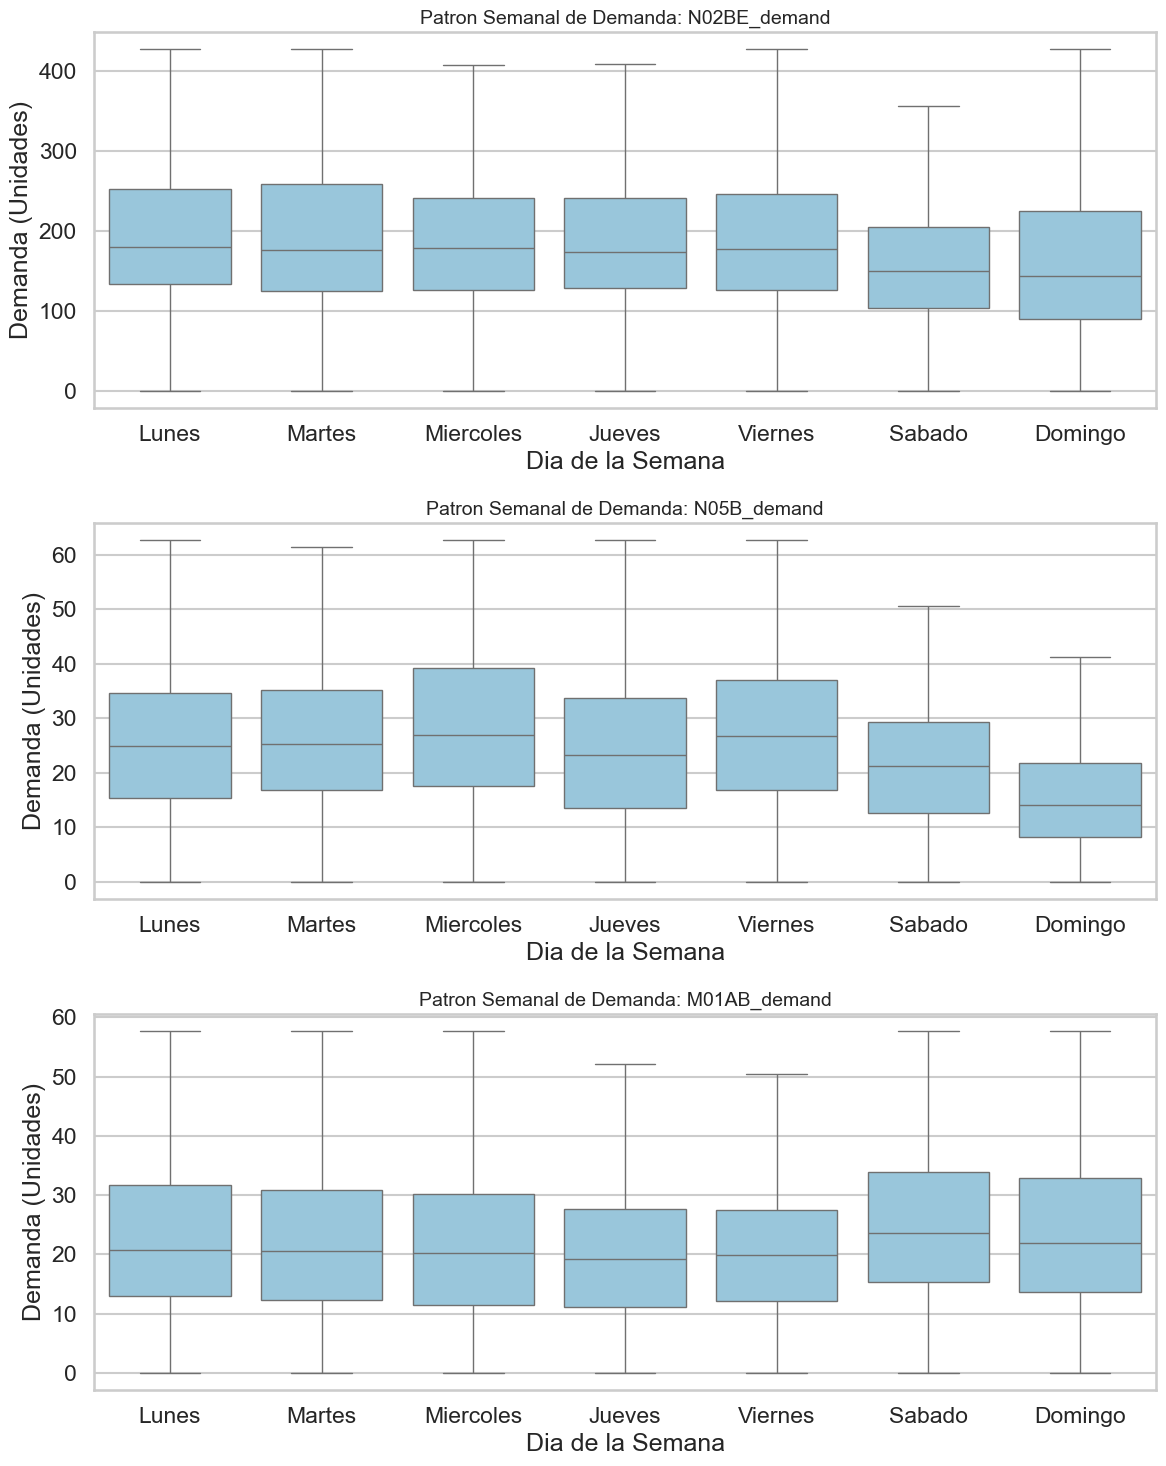

In [18]:
dias_orden = ["Lunes", "Martes", "Miercoles", "Jueves", "Viernes", "Sabado", "Domingo"]
medicamentos = ['N02BE_demand', 'N05B_demand', 'M01AB_demand']
# 2. Crear la figura con 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 15))
for i, med in enumerate(medicamentos):
    sns.boxplot(
        data=df, 
        x="nombre_dia", 
        y=med, 
        order=dias_orden, 
        ax=axes[i], 
        color="#8ecae6",
        showfliers=False # Opcional: oculta puntos extremos para ver mejor las cajas
    )
    axes[i].set_title(f"Patron Semanal de Demanda: {med}", fontsize=14)
    axes[i].set_xlabel("Dia de la Semana")
    axes[i].set_ylabel("Demanda (Unidades)")
plt.tight_layout()
plt.show()

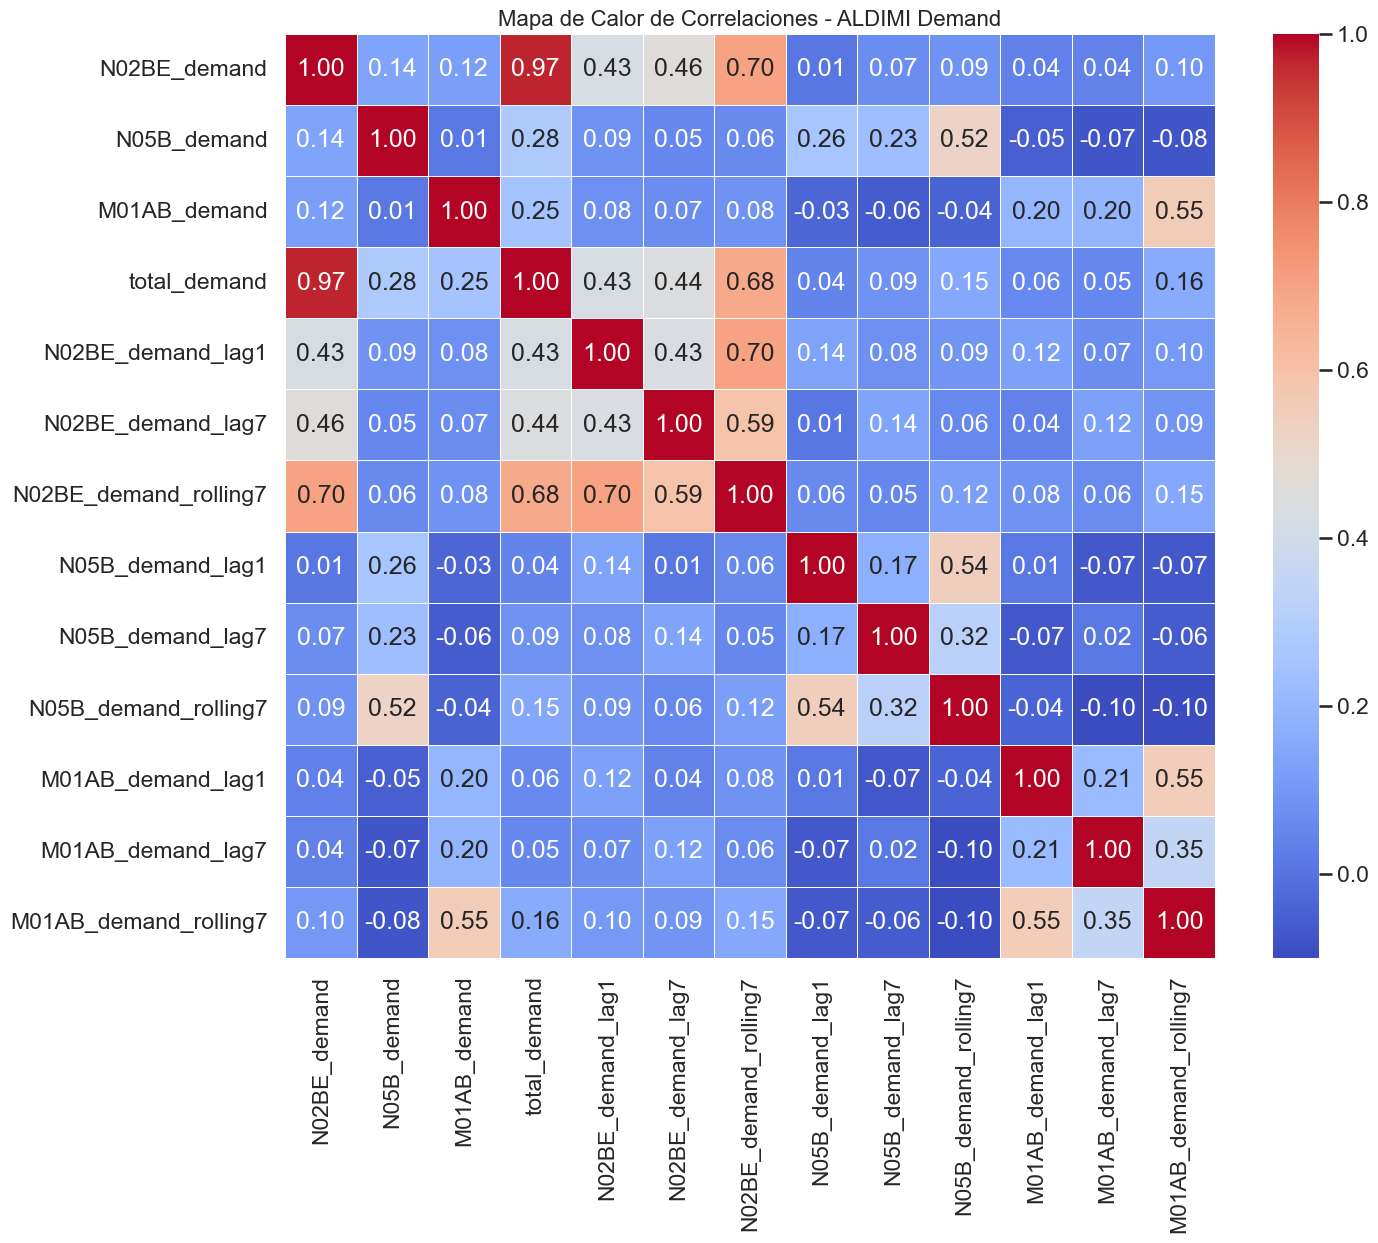

In [19]:
cols_interes = [c for c in df_clean.columns if any(x in c for x in ['demand', 'lag', 'rolling', 'month', 'weekend'])]
matriz_corr = df_clean[cols_interes].corr()
plt.figure(figsize=(15, 12))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones - ALDIMI Demand", fontsize=16)
plt.show()

## Exportación del Dataset Procesado

In [20]:
export_path = '../datos/datos_modelo1/processed/aldimi_demanda_dataset_clean.csv'
df_clean.to_csv(export_path, index=False)
print(f'Dataset exportado exitosamente en: {export_path}')

Dataset exportado exitosamente en: ../datos/datos_modelo1/processed/aldimi_demanda_dataset_clean.csv


## Generación de Censo de Pacientes (Input para Modelo 2)

Para conectar el **Modelo de Clasificación** con el **Modelo de Demanda**, necesitamos un 'Censo': un registro de 100 pacientes individuales con sus características clínicas.

In [21]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(".").resolve().parent
CANCER_DATA = BASE_DIR / "cancer patient data sets.xlsx"
OUTPUT_DIR = BASE_DIR / "datos" / "datos_modelo1" / "raw"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cancer_df = pd.read_excel(CANCER_DATA)
cancer_df = cancer_df.drop("Patient Id", axis=1)

low_patients = cancer_df[cancer_df["Level"] == "Low"].sample(60, random_state=42)
med_patients = cancer_df[cancer_df["Level"] == "Medium"].sample(25, random_state=42)
high_patients = cancer_df[cancer_df["Level"] == "High"].sample(15, random_state=42)

# Unir para crear el censo de 100 personas de ALDIMI
aldimi_censo = pd.concat([low_patients, med_patients, high_patients]).sample(frac=1, random_state=42).reset_index(drop=True)

# Guardar en RAW para que Modelo 1 lo use como entrada
censo_path = OUTPUT_DIR / "aldimi_pacientes_censo.csv"
aldimi_censo.to_csv(censo_path, index=False)

print(f"[OK] Censo de 100 pacientes generado en: {censo_path}")
print(f"Distribución del censo: {aldimi_censo['Level'].value_counts().to_dict()}")

[OK] Censo de 100 pacientes generado en: C:\Users\USER\Documents\2026-1\Machine Learning\ML3037-GRUPO4-ALDIMI\datos\datos_modelo1\raw\aldimi_pacientes_censo.csv
Distribución del censo: {'Low': 60, 'Medium': 25, 'High': 15}


In [22]:
# Generar el de VALIDACIÓN (con etiquetas)
aldimi_censo.to_csv("../datos/datos_modelo2/aldimi_pacientes_censo_VALIDACION.csv", index=False)

# Generar el de INPUT (sin etiquetas)
aldimi_censo.drop('Level', axis=1).to_csv("../datos/datos_modelo2/aldimi_pacientes_censo_INPUT_M1.csv", index=False)